In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

lr_pipeline = joblib.load("../models/lr_baseline.pkl")

train = pd.read_parquet("../data/train_processed.parquet")
test  = pd.read_parquet("../data/test_processed.parquet")

TARGET   = "default"
FEATURES = [c for c in train.columns if c != TARGET]

X_train, y_train = train[FEATURES], train[TARGET]
X_test,  y_test  = test[FEATURES],  test[TARGET]

print(f"X_test shape : {X_test.shape}")

X_test shape : (97761, 39)


In [2]:
# Probabilidades y conversión a score 300-850
def prob_to_score(prob, pdo=20, odds_ref=1, score_ref=600):
    """
    Escala estándar de scorecard bancaria.
    pdo      : puntos para doblar los odds (industry standard: 20)
    odds_ref : odds de referencia en score_ref
    score_ref: score de referencia (600 es estándar)
    """
    factor = pdo / np.log(2)
    offset = score_ref - factor * np.log(odds_ref)
    odds   = (1 - prob) / prob  # odds = P(no default) / P(default)
    score  = offset + factor * np.log(odds)
    return np.clip(score, 300, 850).round().astype(int)

lr_proba  = lr_pipeline.predict_proba(X_test)[:, 1]
lr_scores = prob_to_score(lr_proba)

print(f"Score mínimo  : {lr_scores.min()}")
print(f"Score máximo  : {lr_scores.max()}")
print(f"Score mediana : {np.median(lr_scores):.0f}")
print(f"Score media   : {lr_scores.mean():.0f}")

Score mínimo  : 486
Score máximo  : 706
Score mediana : 606
Score media   : 606


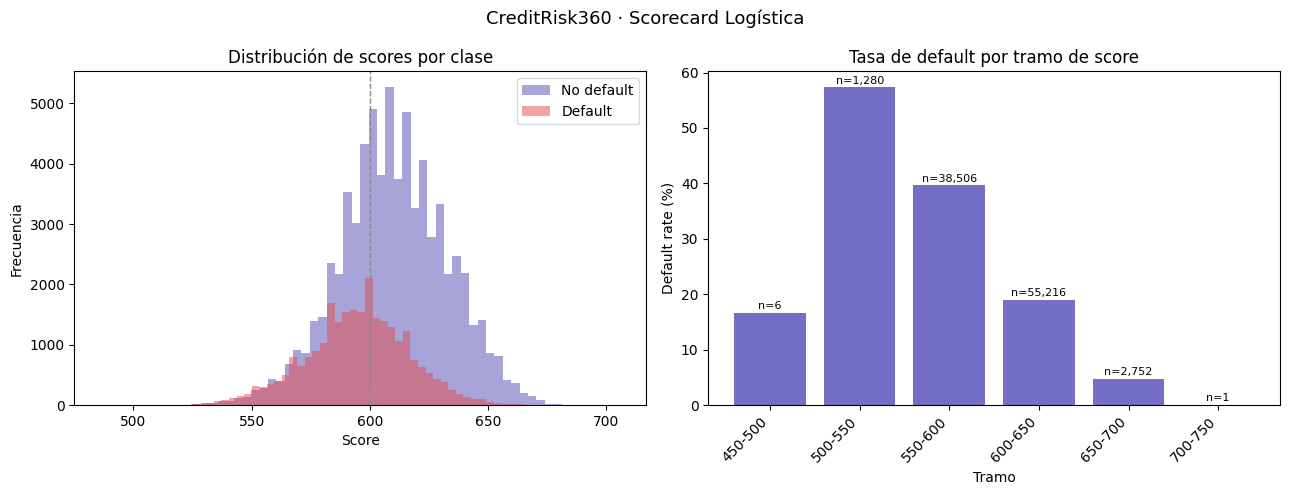

In [3]:
# Distribución de scores por clase
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Histograma por clase
axes[0].hist(lr_scores[y_test == 0], bins=60, alpha=0.5,
             color="#534AB7", label="No default")
axes[0].hist(lr_scores[y_test == 1], bins=60, alpha=0.5,
             color="#E24B4A", label="Default")
axes[0].set(title="Distribución de scores por clase",
            xlabel="Score", ylabel="Frecuencia")
axes[0].legend()
axes[0].axvline(600, color="#888", linestyle="--", lw=1, label="Ref. 600")

# Tasa de default por tramo de score
score_df = pd.DataFrame({"score": lr_scores, "default": y_test.values})
score_df["tramo"] = pd.cut(score_df["score"],
                            bins=[300, 450, 500, 550, 600, 650, 700, 750, 850],
                            labels=["300-450","450-500","500-550","550-600",
                                    "600-650","650-700","700-750","750-850"])

default_rate = score_df.groupby("tramo", observed=True)["default"].mean() * 100
counts        = score_df.groupby("tramo", observed=True)["default"].count()

bars = axes[1].bar(range(len(default_rate)), default_rate.values,
                   color="#534AB7", alpha=0.8)
axes[1].set_xticks(range(len(default_rate)))
axes[1].set_xticklabels(default_rate.index, rotation=45, ha="right")
axes[1].set(title="Tasa de default por tramo de score",
            xlabel="Tramo", ylabel="Default rate (%)")

for bar, count in zip(bars, counts.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f"n={count:,}", ha="center", va="bottom", fontsize=8)

plt.suptitle("CreditRisk360 · Scorecard Logística", fontsize=13)
plt.tight_layout()
plt.savefig("../outputs/scorecard_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

In [4]:
# Tabla resumen por tramo (para README)
summary = pd.DataFrame({
    "n"           : counts,
    "default_rate": default_rate.round(1),
    "pct_total"   : (counts / counts.sum() * 100).round(1)
})
display(summary)
summary.to_csv("../outputs/scorecard_summary.csv")

,n,default_rate,pct_total
tramo,,,
450-500,6,16.7,0.0
500-550,1280,57.3,1.3
550-600,38506,39.7,39.4
600-650,55216,19.0,56.5
650-700,2752,4.8,2.8
700-750,1,0.0,0.0


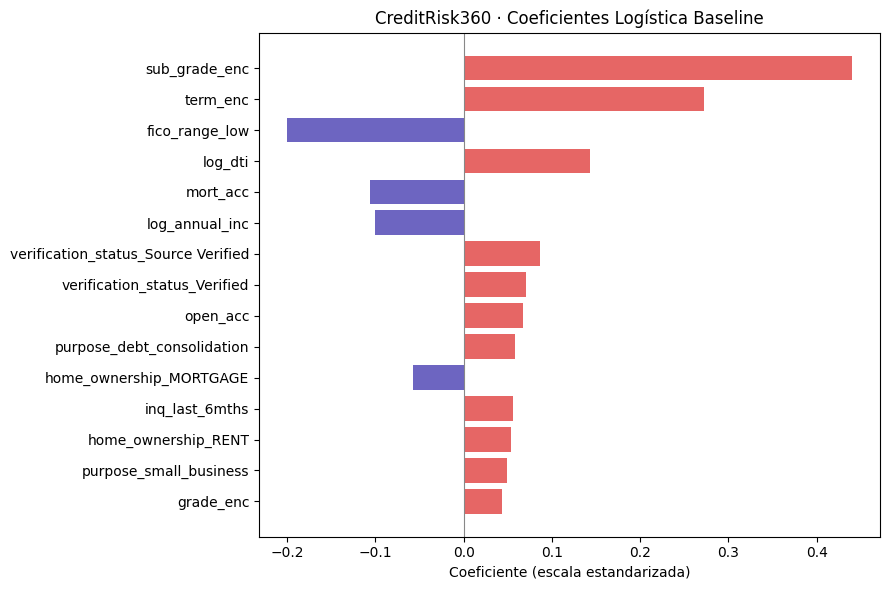

In [5]:
# Coeficientes de la logística (interpretabilidad regulatoria)
lr_model  = lr_pipeline.named_steps["lr"]
scaler    = lr_pipeline.named_steps["scaler"]

coef_df = pd.DataFrame({
    "feature"    : FEATURES,
    "coef"       : lr_model.coef_[0],
    "coef_scaled": lr_model.coef_[0] / scaler.scale_
}).sort_values("coef", key=abs, ascending=False).head(15)

fig, ax = plt.subplots(figsize=(9, 6))
colors = ["#E24B4A" if c > 0 else "#534AB7" for c in coef_df["coef"]]
ax.barh(coef_df["feature"], coef_df["coef"], color=colors, alpha=0.85)
ax.axvline(0, color="#888", lw=0.8)
ax.set(title="CreditRisk360 · Coeficientes Logística Baseline",
       xlabel="Coeficiente (escala estandarizada)")
ax.invert_yaxis()
plt.tight_layout()
plt.savefig("../outputs/scorecard_coeficientes.png", dpi=150, bbox_inches="tight")
plt.show()